<a href="https://colab.research.google.com/github/nunotfc-png/Caeser-Cipher/blob/master/EX4_Risco_Credito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EX04 — Análise e Classificação de Risco de Crédito
**UC: Análise de Dados de Negócio**

---

Scorecard de risco de crédito com **dados reais**. Weight of Evidence (WoE), Information Value (IV), KS Statistic, classes de risco A–E e comparação de modelos.

Contexto: Uma instituição financeira pretende automatizar a decisão de concessão de crédito, atribuindo um score de risco a cada candidato e classificando-o em classes de risco (A = muito baixo → E = muito elevado).

**Dataset:** [Give Me Some Credit — Kaggle 2011](https://www.kaggle.com/datasets/brycecf/give-me-some-credit-dataset)  
150 000 mutuários · 10 variáveis · Target: default em 2 anos · Taxa de default: 6.7%



**Outputs gerados:** `risco_credito_scores.csv` · `information_value.csv` · `perfil_classes_risco.csv` · `risco_eda.png` · `woe_iv.png` · `ks_statistic.png`



## PARTE 0 — SETUP E CARREGAMENTO DO DATASET

In [1]:
# --- Instalação de dependências ---
# !pip install -q kaggle

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GREEN, RED, AMBER, PURPLE = '#0891B2', '#0D9488', '#EF4444', '#D97706', '#7C3AED'

In [2]:
# O dataset pode ser descarregado do Moodle ou diretamente do Kaggle:
# https://www.kaggle.com/datasets/brycecf/give-me-some-credit-dataset

# Outputs ficam em /content/ (sessão temporária):
OUTPUT_DIR = '/content/'
print(f"Directório de output: {OUTPUT_DIR}")

# Carregar o ficheiro "cs-training.csv" do PC para o Colab :
from google.colab import files
uploaded = files.upload()



Directório de output: /content/


Saving cs-training.csv to cs-training (1).csv


In [3]:
# Leitura do ficheiro
df_raw = pd.read_csv('cs-training.csv', index_col=0)
df_raw.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
# Variáveis, tipos e valores em falta
df_raw.info()
print("\nValores em falta:", df_raw.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

## PARTE 1 — DICIONÁRIO DE VARIÁVEIS E CONTEXTO DE NEGÓCIO

In [5]:
# Dicionário das variáveis do dataset
dicionario = pd.DataFrame({
    'Variável': [
        'SeriousDlqin2yrs',
        'RevolvingUtilizationOfUnsecuredLines',
        'age',
        'NumberOfTime30-59DaysPastDueNotWorse',
        'DebtRatio',
        'MonthlyIncome',
        'NumberOfOpenCreditLinesAndLoans',
        'NumberOfTimes90DaysLate',
        'NumberRealEstateLoansOrLines',
        'NumberOfTime60-89DaysPastDueNotWorse',
        'NumberOfDependents'
    ],
    'Descrição': [
        'TARGET: incumprimento ≥90 dias nos 2 anos seguintes (1=sim, 0=não)',
        'Utilização de crédito rotativo (cartões) — rácio saldo/limite',
        'Idade do mutuário (anos)',
        'Nº de vezes com atraso de 30-59 dias (sem piorar)',
        'Rácio dívida/rendimento (inclui empréstimos, pensões)',
        'Rendimento mensal bruto (USD)',
        'Nº de linhas de crédito e empréstimos em aberto',
        'Nº de vezes com atraso ≥90 dias',
        'Nº de empréstimos imobiliários ou linhas de crédito',
        'Nº de vezes com atraso de 60-89 dias (sem piorar)',
        'Nº de dependentes (exc. cônjuge)'
    ]
})
print("\nDicionário de variáveis:")
print(dicionario.to_string(index=False))


Dicionário de variáveis:
                            Variável                                                          Descrição
                    SeriousDlqin2yrs TARGET: incumprimento ≥90 dias nos 2 anos seguintes (1=sim, 0=não)
RevolvingUtilizationOfUnsecuredLines      Utilização de crédito rotativo (cartões) — rácio saldo/limite
                                 age                                           Idade do mutuário (anos)
NumberOfTime30-59DaysPastDueNotWorse                  Nº de vezes com atraso de 30-59 dias (sem piorar)
                           DebtRatio              Rácio dívida/rendimento (inclui empréstimos, pensões)
                       MonthlyIncome                                      Rendimento mensal bruto (USD)
     NumberOfOpenCreditLinesAndLoans                    Nº de linhas de crédito e empréstimos em aberto
             NumberOfTimes90DaysLate                                    Nº de vezes com atraso ≥90 dias
        NumberRealEstateLoansOrLines  

## PARTE 2 — LIMPEZA E PRÉ-PROCESSAMENTO

In [6]:
df = df_raw.copy()

# Renomear colunas para facilitar o trabalho
df.rename(columns={
    'SeriousDlqin2yrs':                          'target',
    'RevolvingUtilizationOfUnsecuredLines':       'util_credito',
    'age':                                        'idade',
    'NumberOfTime30-59DaysPastDueNotWorse':       'atraso_30_59',
    'DebtRatio':                                  'debt_ratio',
    'MonthlyIncome':                              'rendimento',
    'NumberOfOpenCreditLinesAndLoans':            'linhas_credito',
    'NumberOfTimes90DaysLate':                    'atraso_90',
    'NumberRealEstateLoansOrLines':               'imoveis',
    'NumberOfTime60-89DaysPastDueNotWorse':       'atraso_60_89',
    'NumberOfDependents':                         'dependentes'
}, inplace=True)

print("Taxa de incumprimento (default rate):")
print(f"  {df['target'].mean()*100:.2f}%  ({df['target'].sum():,} defaults em {len(df):,} clientes)")


Taxa de incumprimento (default rate):
  6.68%  (10,026 defaults em 150,000 clientes)


In [7]:
# 2a. Tratar valores em falta
# MonthlyIncome — imputar com mediana por idade (proxy de carreira)
print(f"\nRendimento em falta: {df['rendimento'].isnull().sum():,}")
df['rendimento_em_falta'] = df['rendimento'].isnull().astype(int)  # flag útil como feature
df['rendimento'] = df.groupby(
    pd.cut(df['idade'], bins=[0, 30, 40, 50, 60, 120])
)['rendimento'].transform(lambda x: x.fillna(x.median()))
df['rendimento'].fillna(df['rendimento'].median(), inplace=True)

# NumberOfDependents — imputar com moda (0)
print(f"Dependentes em falta: {df['dependentes'].isnull().sum():,}")
df['dependentes'].fillna(df['dependentes'].mode()[0], inplace=True)


Rendimento em falta: 29,731
Dependentes em falta: 3,924


In [8]:
# 2b. Tratar valores anómalos conhecidos
# Utilização de crédito: valores > 1 são anomalias (rácio não pode exceder 100%)
print(f"\nUtil. crédito > 1: {(df['util_credito'] > 1).sum():,} registos")
df['util_credito'] = df['util_credito'].clip(0, 1)

# Idade: registos com idade < 18 são inválidos
print(f"Idade < 18: {(df['idade'] < 18).sum()} registos")
df = df[df['idade'] >= 18].copy()

# Atrasos: valores 96 e 98 são códigos especiais — tratar como outliers (Winsorize)
for col in ['atraso_30_59', 'atraso_60_89', 'atraso_90']:
    upper = df[col][df[col] < 90].quantile(0.99)
    df[col] = df[col].clip(0, upper)
    print(f"  {col}: Winsorize para max={upper:.0f}")


Util. crédito > 1: 3,321 registos
Idade < 18: 1 registos
  atraso_30_59: Winsorize para max=3
  atraso_60_89: Winsorize para max=2
  atraso_90: Winsorize para max=2


In [9]:
# 2c. Criar features adicionais
df['total_atrasos']   = df['atraso_30_59'] + df['atraso_60_89'] + df['atraso_90']
df['rendimento_log']  = np.log1p(df['rendimento'])   # log para reduzir assimetria
df['debt_ratio_clip'] = df['debt_ratio'].clip(0, 5)  # debt_ratio tem outliers extremos

print("\nShape após limpeza:", df.shape)
print("Colunas:", df.columns.tolist())


Shape após limpeza: (149999, 15)
Colunas: ['target', 'util_credito', 'idade', 'atraso_30_59', 'debt_ratio', 'rendimento', 'linhas_credito', 'atraso_90', 'imoveis', 'atraso_60_89', 'dependentes', 'rendimento_em_falta', 'total_atrasos', 'rendimento_log', 'debt_ratio_clip']


In [10]:
# Lista 10 primeiras linhas
df.head(10)

,target,util_credito,idade,atraso_30_59,debt_ratio,rendimento,linhas_credito,atraso_90,imoveis,atraso_60_89,dependentes,rendimento_em_falta,total_atrasos,rendimento_log,debt_ratio_clip
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,2,9.118335,0.802982
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0,7.863651,0.121876
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,2,8.020599,0.085113
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0,8.101981,0.036050
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0,1,11.060196,0.024926
6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0,0,0,8.160804,0.375607
7,0,0.305682,57,0,5710.000000,6307.5,8,0,3,0,0.0,1,0,8.749653,5.000000
8,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0,0,0,8.160804,0.209940
9,0,0.116951,27,0,46.000000,2779.5,2,0,0,0,0.0,1,0,7.930386,5.000000
10,0,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0,0,0,10.072597,0.606291


## PARTE 3 — ANÁLISE EXPLORATÓRIA E PERFIL DE RISCO

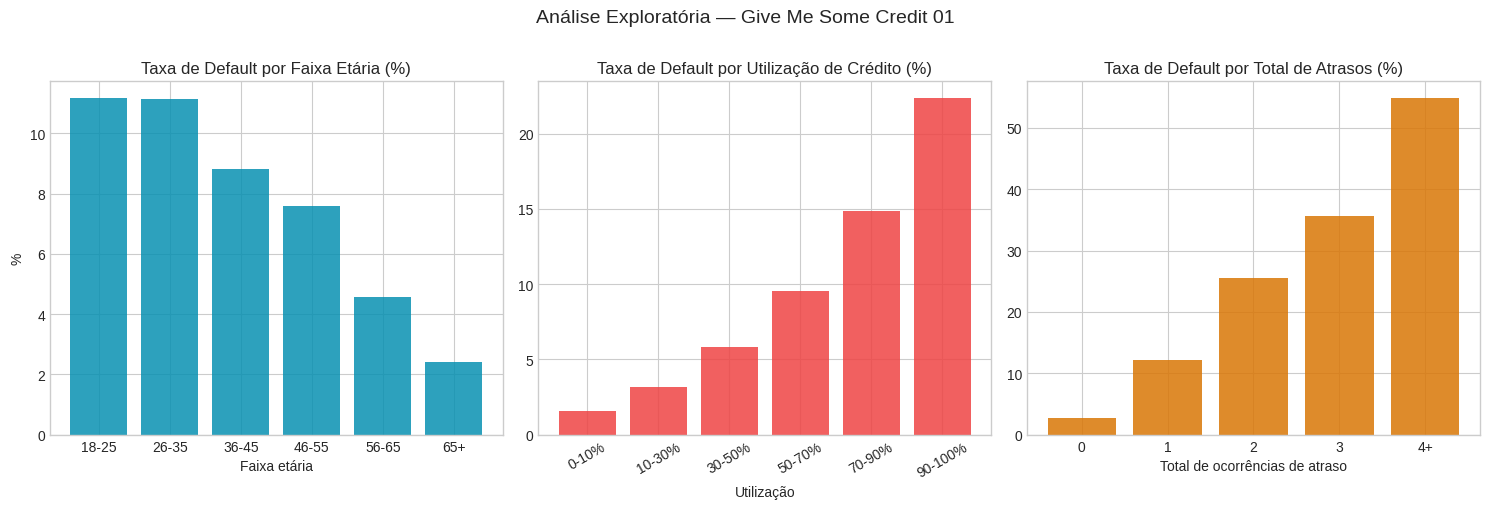

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

# 3a. Taxa de default por faixa etária
df['faixa_etaria'] = pd.cut(df['idade'],
    bins=[17, 25, 35, 45, 55, 65, 120],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])
cr_idade = df.groupby('faixa_etaria', observed=True)['target'].mean() * 100
axes[0].bar(cr_idade.index.astype(str), cr_idade.values, color=BLUE, alpha=0.85)
axes[0].set_title('Taxa de Default por Faixa Etária (%)')
axes[0].set_ylabel('%')
axes[0].set_xlabel('Faixa etária')

# 3b. Taxa de default por utilização do crédito (bins)
df['util_bin'] = pd.cut(df['util_credito'],
    bins=[0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.01],
    labels=['0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-100%'])
cr_util = df.groupby('util_bin', observed=True)['target'].mean() * 100
axes[1].bar(cr_util.index.astype(str), cr_util.values, color=RED, alpha=0.85)
axes[1].set_title('Taxa de Default por Utilização de Crédito (%)')
axes[1].set_xlabel('Utilização')
axes[1].tick_params(axis='x', rotation=30)

# 3c. Taxa de default por nº total de atrasos
atraso_bins = pd.cut(df['total_atrasos'], bins=[-1, 0, 1, 2, 3, 20],
                      labels=['0', '1', '2', '3', '4+'])
cr_atraso = df.groupby(atraso_bins, observed=True)['target'].mean() * 100
axes[2].bar(cr_atraso.index.astype(str), cr_atraso.values, color=AMBER, alpha=0.85)
axes[2].set_title('Taxa de Default por Total de Atrasos (%)')
axes[2].set_xlabel('Total de ocorrências de atraso')

plt.suptitle('Análise Exploratória — Give Me Some Credit 01', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/content/risco_eda01.png', dpi=150, bbox_inches='tight')
plt.show()

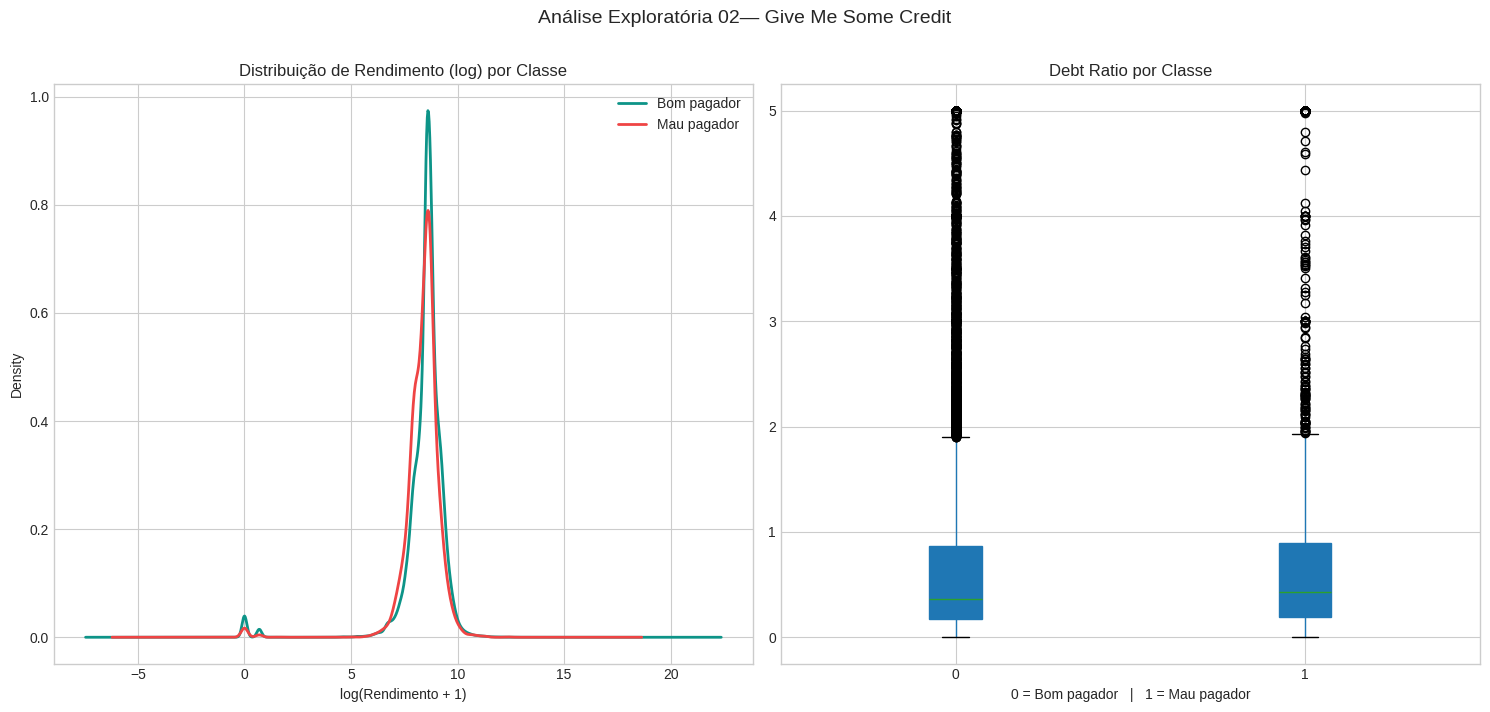

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes = axes.flatten()

# 3d. Distribuição de rendimento (log) por target
for t, label, color in [(0, 'Bom pagador', GREEN), (1, 'Mau pagador', RED)]:
    df[df['target'] == t]['rendimento_log'].plot(kind='kde', ax=axes[0],
                                                  label=label, color=color, linewidth=2)
axes[0].set_title('Distribuição de Rendimento (log) por Classe')
axes[0].set_xlabel('log(Rendimento + 1)')
axes[0].legend()

# 3e. Boxplot de debt_ratio_clip por target
df.boxplot(column='debt_ratio_clip', by='target', ax=axes[1], patch_artist=True)
axes[1].set_title('Debt Ratio por Classe')
axes[1].set_xlabel('0 = Bom pagador   |   1 = Mau pagador')
axes[1].figure.suptitle('')

plt.suptitle('Análise Exploratória 02— Give Me Some Credit', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/content/risco_eda02.png', dpi=150, bbox_inches='tight')
plt.show()

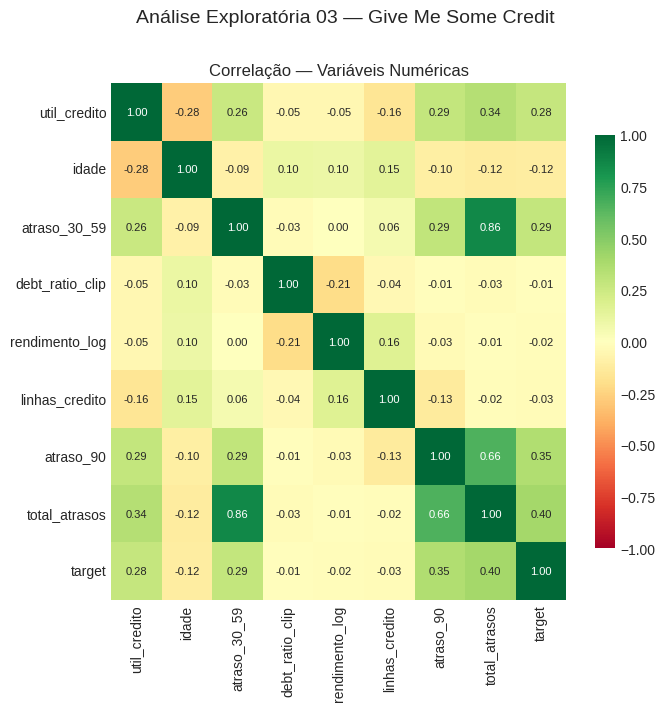

In [13]:
# 3f. Correlação entre variáveis numéricas
fig, axes = plt.subplots(1, 1, figsize=(7, 7))

num_cols = ['util_credito', 'idade', 'atraso_30_59', 'debt_ratio_clip',
            'rendimento_log', 'linhas_credito', 'atraso_90', 'total_atrasos', 'target']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes,
            center=0, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
axes.set_title('Correlação — Variáveis Numéricas')

plt.suptitle('Análise Exploratória 03 — Give Me Some Credit', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/content/risco_eda03.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 4 — WEIGHT OF EVIDENCE (WoE) E INFORMATION VALUE (IV)

In [14]:
# WoE(bin_i) = ln( %Bons_i / %Maus_i )
# IV = Σ (%Bons_i - %Maus_i) × WoE_i

def calcular_woe_iv(df, var_binned, target='target', var_nome=None):
    """
    Calcula WoE e IV para uma variável já agrupada em bins (categórica ou pd.cut).
    Devolve (DataFrame com WoE por bin, IV total).
    """
    total_bons = (df[target] == 0).sum()
    total_maus = (df[target] == 1).sum()
    eps = 1e-6

    stats = df.groupby(var_binned, observed=True)[target].agg(
        Maus = lambda x: (x == 1).sum(),
        Bons = lambda x: (x == 0).sum(),
        Total = 'count'
    ).reset_index()
    stats.rename(columns={var_binned.name if hasattr(var_binned, 'name') else 'index': 'Bin'}, inplace=True)

    stats['pct_bons'] = stats['Bons'] / total_bons
    stats['pct_maus'] = stats['Maus'] / total_maus
    stats['WoE'] = np.log((stats['pct_bons'] + eps) / (stats['pct_maus'] + eps))
    stats['IV_bin'] = (stats['pct_bons'] - stats['pct_maus']) * stats['WoE']
    stats['Default_Rate'] = (stats['Maus'] / stats['Total'] * 100).round(1)

    iv_total = stats['IV_bin'].sum()
    if var_nome:
        stats.insert(0, 'Variável', var_nome)
    return stats, iv_total


### Os critérios para a criação dos bins
---
#### 1. Monotonia do WoE
Os bins devem ser definidos de forma a que o WoE varie de forma monotónica ao longo dos bins ordenados — sempre a crescer ou sempre a decrescer.
#### 2. Volume mínimo por bin
Cada bin deve ter um número mínimo de observações para que o WoE seja estatisticamente estável — uma regra prática comum é pelo menos 5% da amostra total por bin, ou no mínimo 50–100 observações de bons e 50–100 de maus por bin.
#### 3. Significado de negócio
Os limites dos bins devem fazer sentido para um profissional da área. Para a utilização do crédito, os limites 10%, 30%, 50%, 75%, 100% reflectem limiares usados na indústria de crédito: abaixo de 30% é considerado saudável, acima de 75% é um sinal de alerta.
#### 4. Métodos automáticos de binning óptimo
Quando não há intuição de negócio ou quando se quer validar a escolha manual, usam-se algoritmos.

Em baixo, os bins foram definidos manualmente com critério de negócio, o que é o método padrão em scorecards regulados porque é auditável e interpretável.

In [15]:
# Definir bins para cada variável contínua
bins_config = {
    'util_credito': {
        'cut': pd.cut(df['util_credito'],
                      bins=[0, 0.1, 0.3, 0.5, 0.75, 1.01],
                      labels=['0-10%', '10-30%', '30-50%', '50-75%', '75-100%']),
        'nome': 'Utilização de Crédito'
    },
    'idade': {
        'cut': pd.cut(df['idade'],
                      bins=[17, 30, 40, 50, 60, 120],
                      labels=['18-30', '31-40', '41-50', '51-60', '60+']),
        'nome': 'Idade'
    },
    'total_atrasos': {
        'cut': pd.cut(df['total_atrasos'],
                      bins=[-1, 0, 1, 2, 20],
                      labels=['0', '1', '2', '3+']),
        'nome': 'Total de Atrasos'
    },
    'rendimento_log': {
        'cut': pd.cut(df['rendimento_log'],
                      bins=[0, 8, 9, 10, 11, 20],
                      labels=['<8', '8-9', '9-10', '10-11', '>11']),
        'nome': 'Rendimento (log)'
    },
    'debt_ratio_clip': {
        'cut': pd.cut(df['debt_ratio_clip'],
                      bins=[-0.01, 0.1, 0.3, 0.5, 1.0, 5.01],
                      labels=['<0.1', '0.1-0.3', '0.3-0.5', '0.5-1.0', '>1.0']),
        'nome': 'Debt Ratio'
    },
    'linhas_credito': {
        'cut': pd.cut(df['linhas_credito'],
                      bins=[-1, 2, 5, 10, 20, 100],
                      labels=['0-2', '3-5', '6-10', '11-20', '20+']),
        'nome': 'Linhas de Crédito'
    },
}

In [16]:
# Calcular WoE e IV para cada variável

iv_resultados = {}
woe_tabelas = {}

for var, config in bins_config.items():
    woe_df, iv = calcular_woe_iv(df, config['cut'], var_nome=config['nome'])
    iv_resultados[config['nome']] = iv
    woe_tabelas[var] = woe_df
    print(f"  {config['nome']:30s}  IV = {iv:.4f}")

iv_series = pd.Series(iv_resultados).sort_values(ascending=False)

# Interpretação do IV:
#   < 0.02  → sem poder preditivo
#   0.02–0.1 → fraco
#   0.1–0.3  → médio
#   > 0.3   → forte (verificar data leakage se > 0.5)

  Utilização de Crédito           IV = 1.0681
  Idade                           IV = 0.2324
  Total de Atrasos                IV = 1.4115
  Rendimento (log)                IV = 0.0578
  Debt Ratio                      IV = 0.0382
  Linhas de Crédito               IV = 0.0786


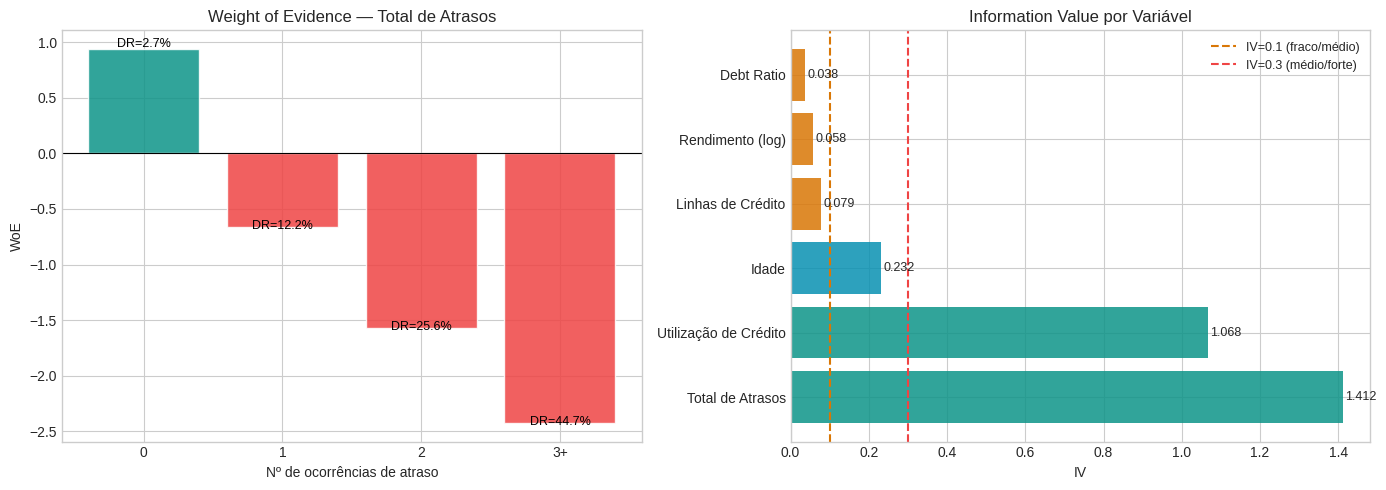


Variáveis por poder preditivo:
  Total de Atrasos                IV=1.4115  → Forte
  Utilização de Crédito           IV=1.0681  → Forte
  Idade                           IV=0.2324  → Médio
  Linhas de Crédito               IV=0.0786  → Fraco
  Rendimento (log)                IV=0.0578  → Fraco
  Debt Ratio                      IV=0.0382  → Fraco


In [17]:
# Visualizar WoE da variável mais preditiva
top_var = list(bins_config.keys())[
    list(iv_resultados.values()).index(max(iv_resultados.values()))
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WoE do total de atrasos (geralmente a variável mais preditiva)
woe_atrasos = woe_tabelas['total_atrasos']
cores_woe = [GREEN if w > 0 else RED for w in woe_atrasos['WoE']]
axes[0].bar(woe_atrasos.iloc[:, 1].astype(str), woe_atrasos['WoE'],
            color=cores_woe, alpha=0.85, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
for i, (woe, dr) in enumerate(zip(woe_atrasos['WoE'], woe_atrasos['Default_Rate'])):
    axes[0].text(i, woe + 0.02 * np.sign(woe), f'DR={dr}%', ha='center',
                 fontsize=9, color='black')
axes[0].set_title('Weight of Evidence — Total de Atrasos')
axes[0].set_xlabel('Nº de ocorrências de atraso')
axes[0].set_ylabel('WoE')

# IV de todas as variáveis
colors_iv = [GREEN if v > 0.3 else BLUE if v > 0.1 else AMBER for v in iv_series.values]
bars = axes[1].barh(iv_series.index, iv_series.values, color=colors_iv, alpha=0.85)
axes[1].axvline(0.1, color=AMBER, linestyle='--', linewidth=1.5, label='IV=0.1 (fraco/médio)')
axes[1].axvline(0.3, color=RED,   linestyle='--', linewidth=1.5, label='IV=0.3 (médio/forte)')
for bar, v in zip(bars, iv_series.values):
    axes[1].text(v + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=9)
axes[1].set_title('Information Value por Variável')
axes[1].set_xlabel('IV')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/woe_iv.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVariáveis por poder preditivo:")
for nome, iv in iv_series.items():
    cat = 'Forte' if iv > 0.3 else 'Médio' if iv > 0.1 else 'Fraco' if iv > 0.02 else 'Sem poder'
    print(f"  {nome:30s}  IV={iv:.4f}  → {cat}")

## PARTE 5 — CONSTRUÇÃO DO SCORECARD (REGRESSÃO LOGÍSTICA + WoE)

In [18]:
# Substituir variáveis originais pelos respectivos WoE
# Isto é a abordagem clássica de scorecard: usar WoE como input da LR
for var, config in bins_config.items():
    woe_map = dict(zip(
        woe_tabelas[var].iloc[:, 1].astype(str),
        woe_tabelas[var]['WoE']
    ))
    df[f'{var}_woe'] = config['cut'].astype(str).map(woe_map)

# Features para o modelo
woe_features = [f'{v}_woe' for v in bins_config.keys()]

# Adicionar variáveis sem transformação WoE que podem ser úteis
extra_features = ['imoveis', 'dependentes', 'rendimento_em_falta']



In [19]:
features = woe_features + extra_features
X = df[features].fillna(0)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Treino: {len(X_train):,}  |  Teste: {len(X_test):,}")
print(f"Default rate treino: {y_train.mean()*100:.2f}%  |  teste: {y_test.mean()*100:.2f}%")


Treino: 112,499  |  Teste: 37,500
Default rate treino: 6.68%  |  teste: 6.69%



Score médio — todos:            630
Score médio — bons pagadores:   640
Score médio — maus pagadores:   497


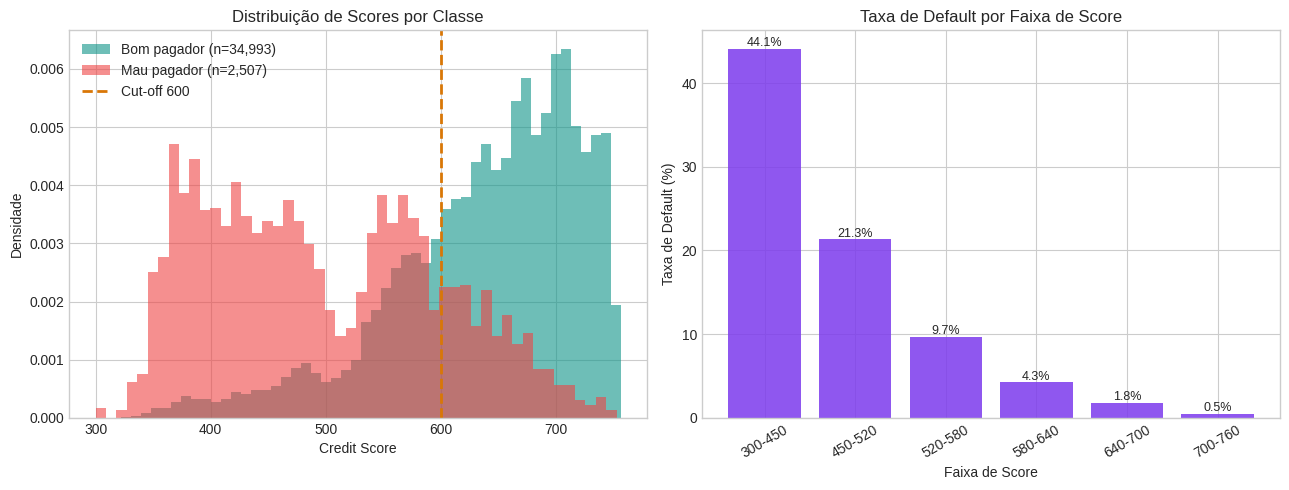

In [20]:

# Regressão Logística — não precisa de normalização quando usa WoE (já escalado)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)

y_prob_train = lr.predict_proba(X_train_sc)[:, 1]
y_prob_test  = lr.predict_proba(X_test_sc)[:, 1]

# Converter probabilidade em credit score (escala FICO: 300–850)
def prob_to_score(prob, min_s=300, max_s=850):
    prob = np.clip(prob, 1e-6, 1 - 1e-6)
    log_odds = np.log(prob / (1 - prob))
    # Calibrar para que log_odds=0 → score=575 (ponto médio)
    return np.clip(max_s - (max_s - min_s) / 2 * (1 + log_odds / 4), min_s, max_s)

train_scores = prob_to_score(y_prob_train)
test_scores  = prob_to_score(y_prob_test)

print(f"\nScore médio — todos:            {test_scores.mean():.0f}")
print(f"Score médio — bons pagadores:   {test_scores[y_test == 0].mean():.0f}")
print(f"Score médio — maus pagadores:   {test_scores[y_test == 1].mean():.0f}")

# Visualizar distribuição de scores
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(test_scores[y_test == 0], bins=50, alpha=0.6, color=GREEN,
             label=f'Bom pagador (n={int((y_test==0).sum()):,})', density=True)
axes[0].hist(test_scores[y_test == 1], bins=50, alpha=0.6, color=RED,
             label=f'Mau pagador (n={int((y_test==1).sum()):,})', density=True)
axes[0].axvline(600, color=AMBER, linestyle='--', linewidth=2, label='Cut-off 600')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição de Scores por Classe')
axes[0].legend()

# Taxa de default por faixa de score
score_bins = pd.cut(test_scores, bins=[300, 450, 520, 580, 640, 700, 760, 850],
                     labels=['300-450', '450-520', '520-580', '580-640',
                             '640-700', '700-760', '760-850'])
dr_por_score = pd.DataFrame({'score_bin': score_bins, 'target': y_test.values}
                            ).groupby('score_bin', observed=True)['target'].mean() * 100
axes[1].bar(dr_por_score.index.astype(str), dr_por_score.values, color=PURPLE, alpha=0.85)
axes[1].set_xlabel('Faixa de Score')
axes[1].set_ylabel('Taxa de Default (%)')
axes[1].set_title('Taxa de Default por Faixa de Score')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(dr_por_score.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/scorecard_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 6 — CLASSES DE RISCO E COMPARAÇÃO DE MODELOS


Perfil por Classe de Risco:
                       N Default_Rate  Score_Medio  Prob_Media
Classe_Risco                                                  
A — Muito Baixo     1973         0.4%        746.6         7.6
B — Baixo          13289         0.9%        703.9        13.6
C — Moderado       10849         3.1%        637.2        29.2
D — Elevado         6917         8.5%        566.0        53.2
E — Muito Elevado   4472        32.6%        443.2        85.2


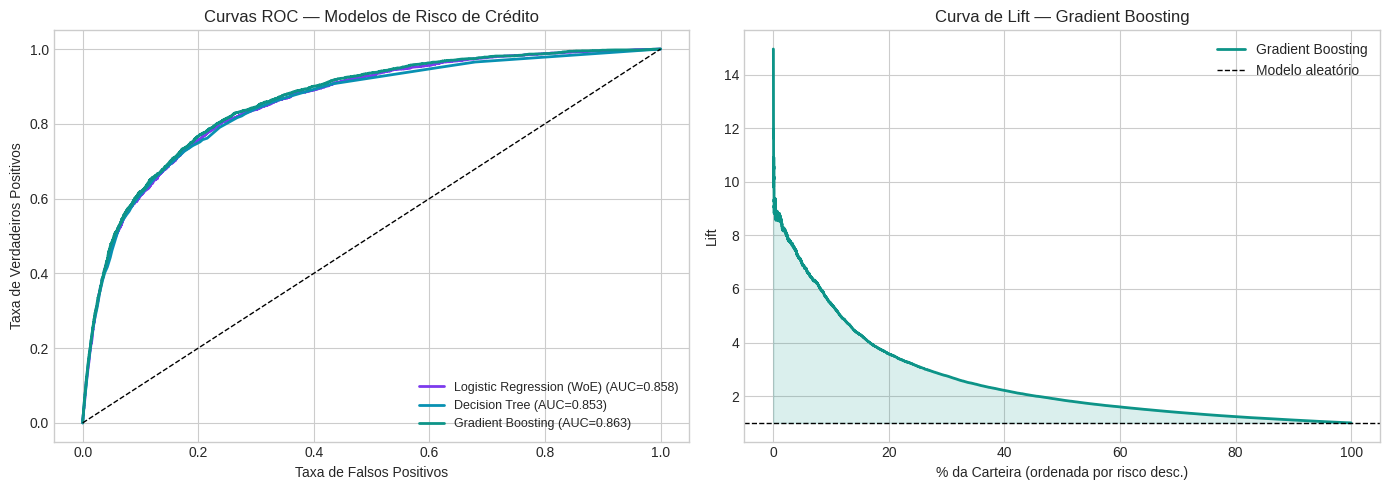

In [21]:
def classificar_risco(score):
    if   score >= 740: return 'A — Muito Baixo'
    elif score >= 670: return 'B — Baixo'
    elif score >= 600: return 'C — Moderado'
    elif score >= 520: return 'D — Elevado'
    else:              return 'E — Muito Elevado'

df_test = pd.DataFrame({
    'Score':        test_scores.round(0).astype(int),
    'Prob_Default': (y_prob_test * 100).round(2),
    'Classe_Real':  y_test.values,
    'Classe_Risco': [classificar_risco(s) for s in test_scores]
})

# Perfil por classe de risco
perfil = df_test.groupby('Classe_Risco').agg(
    N             = ('Classe_Real', 'count'),
    Default_Rate  = ('Classe_Real', lambda x: f"{x.mean()*100:.1f}%"),
    Score_Medio   = ('Score', 'mean'),
    Prob_Media    = ('Prob_Default', 'mean')
).round(1)
print("\nPerfil por Classe de Risco:")
print(perfil.to_string())

# Comparar 3 modelos
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=500, random_state=42)
gb = GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                learning_rate=0.05, random_state=42)

modelos = {
    'Logistic Regression (WoE)': (lr, X_train_sc, X_test_sc),
    'Decision Tree':             (dt, X_train_sc, X_test_sc),
    'Gradient Boosting':         (gb, X_train_sc, X_test_sc),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cores_mod = [PURPLE, BLUE, GREEN]

resultados_mod = {}
for (name, (model, Xtr, Xte)), cor in zip(modelos.items(), cores_mod):
    if name != 'Logistic Regression (WoE)':
        model.fit(Xtr, y_train)
    yp = model.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(y_test, yp)
    fpr, tpr, _ = roc_curve(y_test, yp)
    resultados_mod[name] = {'auc': auc, 'prob': yp}
    axes[0].plot(fpr, tpr, linewidth=2, color=cor, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('Curvas ROC — Modelos de Risco de Crédito')
axes[0].legend(fontsize=9)

# Curva de Lift — Gradient Boosting
gb_prob = resultados_mod['Gradient Boosting']['prob']
idx_sorted = np.argsort(-gb_prob)
y_sorted   = y_test.values[idx_sorted]
cum_defaults = np.cumsum(y_sorted)
pct_pop  = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
lift_vals = (cum_defaults / y_test.sum()) / pct_pop

axes[1].plot(pct_pop * 100, lift_vals, color=GREEN, linewidth=2, label='Gradient Boosting')
axes[1].axhline(1, color='k', linestyle='--', linewidth=1, label='Modelo aleatório')
axes[1].fill_between(pct_pop * 100, 1, lift_vals,
                     where=lift_vals > 1, alpha=0.15, color=GREEN)
axes[1].set_xlabel('% da Carteira (ordenada por risco desc.)')
axes[1].set_ylabel('Lift')
axes[1].set_title('Curva de Lift — Gradient Boosting')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/risco_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 7 — KS STATISTIC E INTERPRETABILIDADE

  Logistic Regression (WoE)            AUC=0.858  KS=56.4%
  Decision Tree                        AUC=0.853  KS=55.3%
  Gradient Boosting                    AUC=0.863  KS=56.8%


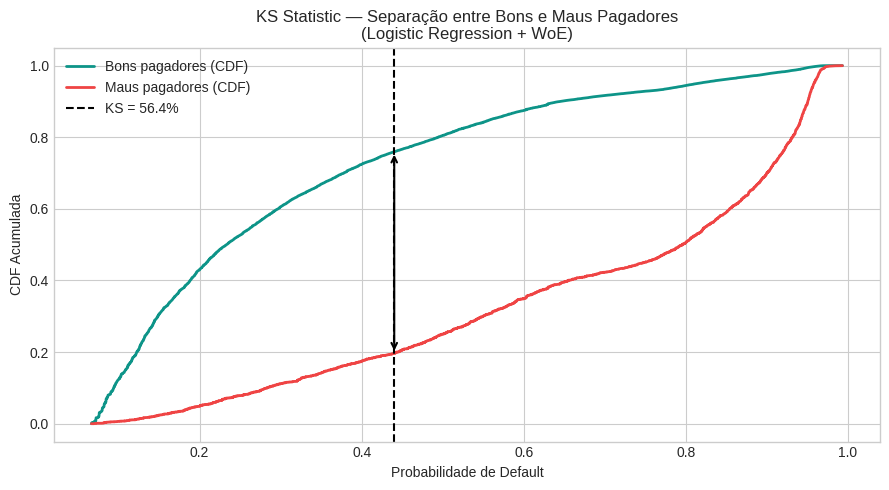

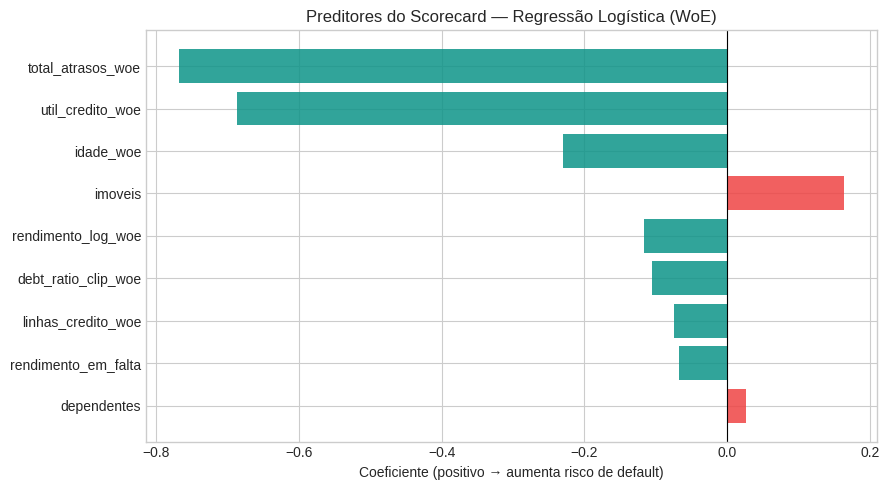

In [22]:
# Kolmogorov-Smirnov: separação entre distribuições de bons e maus
from scipy.stats import ks_2samp

for name, res in resultados_mod.items():
    prob_bons = res['prob'][y_test == 0]
    prob_maus = res['prob'][y_test == 1]
    ks_stat, _ = ks_2samp(prob_bons, prob_maus)
    print(f"  {name:35s}  AUC={res['auc']:.3f}  KS={ks_stat*100:.1f}%")

# Visualizar KS do modelo LR
lr_prob = resultados_mod['Logistic Regression (WoE)']['prob']
sorted_scores_all = np.sort(np.unique(lr_prob))
cdf_bons = np.array([(lr_prob[y_test == 0] <= t).mean() for t in sorted_scores_all])
cdf_maus = np.array([(lr_prob[y_test == 1] <= t).mean() for t in sorted_scores_all])
ks_idx   = np.argmax(np.abs(cdf_bons - cdf_maus))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sorted_scores_all, cdf_bons, color=GREEN, linewidth=2, label='Bons pagadores (CDF)')
ax.plot(sorted_scores_all, cdf_maus, color=RED,   linewidth=2, label='Maus pagadores (CDF)')
ax.axvline(sorted_scores_all[ks_idx], color='black', linestyle='--', linewidth=1.5,
           label=f'KS = {np.abs(cdf_bons[ks_idx]-cdf_maus[ks_idx])*100:.1f}%')
ax.annotate('', xy=(sorted_scores_all[ks_idx], cdf_maus[ks_idx]),
            xytext=(sorted_scores_all[ks_idx], cdf_bons[ks_idx]),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.set_xlabel('Probabilidade de Default')
ax.set_ylabel('CDF Acumulada')
ax.set_title('KS Statistic — Separação entre Bons e Maus Pagadores\n(Logistic Regression + WoE)')
ax.legend()
plt.tight_layout()
plt.savefig('/content/ks_statistic.png', dpi=150, bbox_inches='tight')
plt.show()

# Coeficientes da LR
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coeficiente': lr.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
cores_coef = [RED if c > 0 else GREEN for c in coef_df['Coeficiente']]
ax.barh(range(len(coef_df)), coef_df['Coeficiente'].values, color=cores_coef, alpha=0.85)
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df['Feature'].values, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (positivo → aumenta risco de default)')
ax.set_title('Preditores do Scorecard — Regressão Logística (WoE)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('/content/risco_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 8 — EXPORTAR PARA POWER BI

In [23]:
# Aplicar scorecard a todos os dados de teste
df_export = df_test.copy()
df_export['Prob_Default_pct'] = df_export['Prob_Default']
df_export['Score'] = df_export['Score']

# Adicionar variáveis originais para enriquecer o dashboard
colunas_orig = ['idade', 'util_credito', 'rendimento', 'total_atrasos',
                'debt_ratio_clip', 'linhas_credito']
df_export = df_export.join(df.loc[X_test.index, colunas_orig].reset_index(drop=True))
df_export.to_csv('/content/risco_credito_scores.csv', index=False)

# Information Value para visualização
iv_export = pd.DataFrame({
    'Variavel': iv_series.index,
    'IV':       iv_series.values.round(4),
    'Poder':    ['Forte' if v > 0.3 else 'Médio' if v > 0.1 else 'Fraco'
                 for v in iv_series.values]
})
iv_export.to_csv('/content/information_value.csv', index=False)

# Perfil de risco por classe para dashboard executivo
perfil_export = df_test.groupby('Classe_Risco').agg(
    N             = ('Classe_Real', 'count'),
    Default_Rate  = ('Classe_Real', 'mean'),
    Score_Medio   = ('Score', 'mean'),
    Prob_Media    = ('Prob_Default', 'mean')
).round(3).reset_index()
perfil_export.to_csv('/content/perfil_classes_risco.csv', index=False)

print("Ficheiros exportados para Power BI:")
print("  risco_credito_scores.csv    — score, classe e perfil por cliente")
print("  information_value.csv       — IV por variável")
print("  perfil_classes_risco.csv    — taxa de default e score médio por classe")
print()
print("Sugestão de dashboard Power BI:")
print("  - Gauge:      Score médio da carteira vs target (ex: ≥ 620)")
print("  - Donut:      Distribuição de clientes por classe (A/B/C/D/E)")
print("  - Bar chart:  Taxa de default por classe de risco")
print("  - Line chart: Score médio por faixa etária")
print("  - Tabela:     Clientes classe D e E → candidatos a revisão manual")
print("  - Slicer:     Filtrar por classe de risco, faixa etária, utilização")

Ficheiros exportados para Power BI:
  risco_credito_scores.csv    — score, classe e perfil por cliente
  information_value.csv       — IV por variável
  perfil_classes_risco.csv    — taxa de default e score médio por classe

Sugestão de dashboard Power BI:
  - Gauge:      Score médio da carteira vs target (ex: ≥ 620)
  - Donut:      Distribuição de clientes por classe (A/B/C/D/E)
  - Bar chart:  Taxa de default por classe de risco
  - Line chart: Score médio por faixa etária
  - Tabela:     Clientes classe D e E → candidatos a revisão manual
  - Slicer:     Filtrar por classe de risco, faixa etária, utilização


> PERGUNTAS DE REFLEXÃO

1. O WoE do bin '3+' atrasos é fortemente negativo.
   O que comunica ao gestor de risco sobre este grupo de clientes?
   Que acção concreta tomaria a instituição para estes clientes?

2. A Regressão Logística tem AUC inferior ao Gradient Boosting,
   mas é preferida em contextos regulados (Basileia III, IFRS 9).
   Identifica duas razões concretas para essa preferência.

3. O dataset tem uma taxa de default de 6.7%.
   O que acontece ao KS e à AUC se baixarmos o class_weight
   ou se não usarmos class_weight='balanced'?
   Experimenta e compara os resultados.

4. EXTENSÃO — Expected Loss (EL):
   EL = PD × LGD × EAD
   Assumindo LGD = 0.45 e EAD = rendimento × 6 (6 meses de exposição):
   - Calcula o EL médio por classe de risco
   - Qual a classe com maior EL total (não médio)?
   - O resultado surpreende-te? Porquê?

5. EXTENSÃO — PSI:
   Divide o dataset de teste em dois semestres (primeiros e últimos 50%).
   Calcula o PSI da variável 'util_credito' entre os dois períodos.
   O modelo estaria estável ou requereria recalibração?